# Kalman Filter and RTS Smoother

This notebook demonstrates the gaussx Kalman filter and Rauch-Tung-Striebel
(RTS) smoother recipes on a simple linear dynamical system.

**What you'll learn:**

1. Setting up a linear-Gaussian state-space model
2. Running `gaussx.kalman_filter` for online state estimation
3. Running `gaussx.rts_smoother` for offline smoothing
4. Comparing filtered vs smoothed estimates
5. The filter is fully differentiable via JAX

## Background

A linear-Gaussian state-space model (SSM) is defined by:

$$x_t = A \, x_{t-1} + q_t, \quad q_t \sim \mathcal{N}(0, Q)$$
$$y_t = H \, x_t + r_t, \quad r_t \sim \mathcal{N}(0, R)$$

The **Kalman filter** computes the filtering distribution
$p(x_t \mid y_{1:t})$ in a single forward pass.
The **RTS smoother** then refines these estimates using future observations,
giving the smoothing distribution $p(x_t \mid y_{1:T})$.

The smoother always has lower (or equal) posterior variance than the filter,
because it conditions on strictly more data.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import gaussx


jax.config.update("jax_enable_x64", True)

## Define the model

We use a 2D state $x_t = [\text{position}, \text{velocity}]^\top$ with
a **damped oscillator** transition (discretized spring-mass-damper).
Only position is observed with noise.

- $A$: discretized spring-mass-damper transition
- $H = \begin{bmatrix} 1 & 0 \end{bmatrix}$ (observe position only)
- $Q$: process noise driving the oscillator
- $R = [0.5]$: observation noise variance

In [2]:
dt = 0.1
T = 200

# Damped oscillator: omega=1.0 rad/s, damping gamma=0.15
omega, gamma = 1.0, 0.15
A = jnp.array([[1.0, dt], [-(omega**2) * dt, 1.0 - gamma * dt]])

# Observation matrix (observe position only)
H = jnp.array([[1.0, 0.0]])

# Process noise covariance
q_var = 0.3
Q = q_var * jnp.array([[dt**3 / 3, dt**2 / 2], [dt**2 / 2, dt]])

# Observation noise covariance
R = jnp.array([[0.5]])

print("A =\n", A)
print("H =", H)
print("Q =\n", Q)
print("R =", R)

A =
 [[ 1.     0.1  ]
 [-0.1    0.985]]
H = [[1. 0.]]
Q =
 [[0.0001 0.0015]
 [0.0015 0.03  ]]
R = [[0.5]]


## Generate data

We simulate the true trajectory **from the model itself**, so the
Kalman filter's assumptions are satisfied. This shows the filter
performing as designed — tracking a randomly evolving state from
noisy observations.

In [3]:
key = jax.random.PRNGKey(42)


# Simulate states from the model
def simulate_step(carry, key_t):
    x = carry
    k1, k2 = jax.random.split(key_t)
    q_t = jax.random.multivariate_normal(k1, jnp.zeros(2), Q)
    x_new = A @ x + q_t
    r_t = jax.random.multivariate_normal(k2, jnp.zeros(1), R)
    y_t = H @ x_new + r_t
    return x_new, (x_new, y_t)


x0 = jnp.array([3.0, 0.0])  # displaced from equilibrium, at rest
keys = jax.random.split(key, T)
_, (true_states, observations) = jax.lax.scan(simulate_step, x0, keys)

times = jnp.arange(T) * dt
true_position = true_states[:, 0]

print("true_states shape:", true_states.shape)
print("observations shape:", observations.shape)

true_states shape: (200, 2)
observations shape: (200, 1)


## Run Kalman filter

`gaussx.kalman_filter` takes the model matrices and observations,
returning a `FilterState` with filtered means, covariances, and the
total log-likelihood.

In [4]:
# Initial state: zero mean, moderate uncertainty
init_mean = jnp.zeros(2)
init_cov = jnp.eye(2) * 4.0

filter_state = gaussx.kalman_filter(A, H, Q, R, observations, init_mean, init_cov)

print("Filtered means shape:", filter_state.filtered_means.shape)
print("Filtered covs shape:", filter_state.filtered_covs.shape)
print("Log-likelihood:", filter_state.log_likelihood)

Filtered means shape: (200, 2)
Filtered covs shape: (200, 2, 2)
Log-likelihood: -223.3188576581507


## Plot filtered results

The filtered estimate tracks the true position closely despite the noisy
observations. The shaded band shows the $\pm 2\sigma$ credible interval.

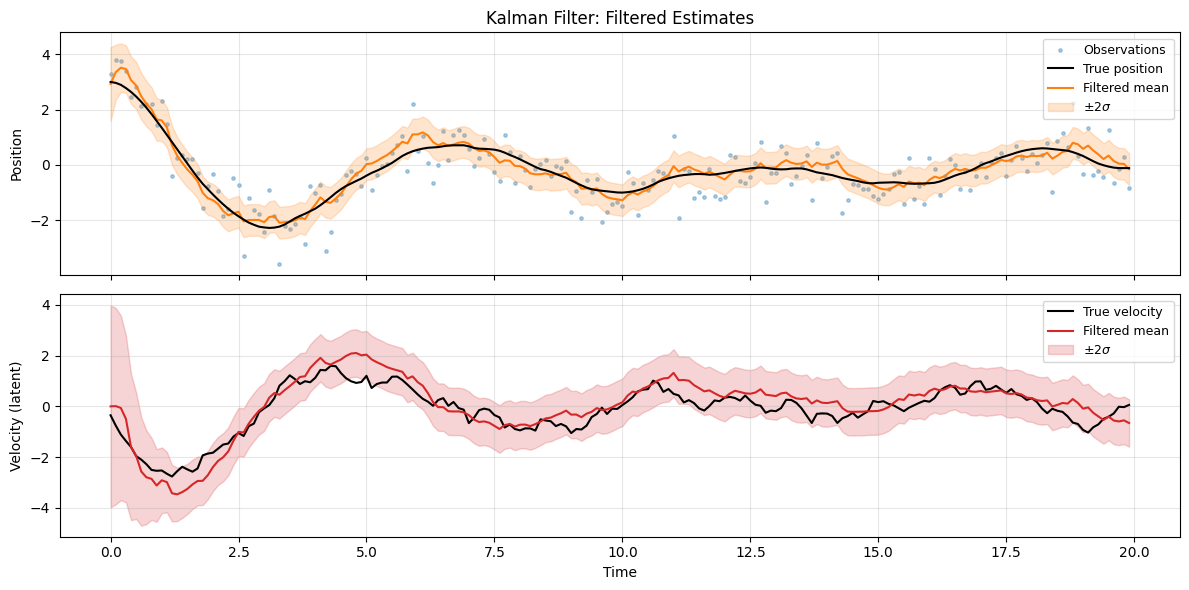

In [5]:
filt_pos_mean = filter_state.filtered_means[:, 0]
filt_pos_std = jnp.sqrt(filter_state.filtered_covs[:, 0, 0])
filt_vel_mean = filter_state.filtered_means[:, 1]
filt_vel_std = jnp.sqrt(filter_state.filtered_covs[:, 1, 1])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Position
ax = axes[0]
ax.scatter(
    times, observations[:, 0], s=6, c="C0", alpha=0.35, label="Observations", zorder=1
)
ax.plot(times, true_position, "k-", lw=1.5, label="True position", zorder=3)
ax.plot(times, filt_pos_mean, "C1-", lw=1.5, label="Filtered mean", zorder=2)
ax.fill_between(
    times,
    filt_pos_mean - 2 * filt_pos_std,
    filt_pos_mean + 2 * filt_pos_std,
    color="C1",
    alpha=0.2,
    label=r"$\pm 2\sigma$",
)
ax.set_ylabel("Position")
ax.set_title("Kalman Filter: Filtered Estimates")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

# Velocity (inferred, never directly observed)
ax = axes[1]
ax.plot(times, true_states[:, 1], "k-", lw=1.5, label="True velocity")
ax.plot(times, filt_vel_mean, "C3-", lw=1.5, label="Filtered mean")
ax.fill_between(
    times,
    filt_vel_mean - 2 * filt_vel_std,
    filt_vel_mean + 2 * filt_vel_std,
    color="C3",
    alpha=0.2,
    label=r"$\pm 2\sigma$",
)
ax.set_xlabel("Time")
ax.set_ylabel("Velocity (latent)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Run RTS smoother

The RTS smoother takes the filter output and refines the estimates
using a backward pass. This produces tighter credible intervals,
especially in the middle of the time series.

In [6]:
smoothed_means, smoothed_covs = gaussx.rts_smoother(filter_state, A, Q)

print("Smoothed means shape:", smoothed_means.shape)
print("Smoothed covs shape:", smoothed_covs.shape)

Smoothed means shape: (200, 2)
Smoothed covs shape: (200, 2, 2)


## Plot filtered vs smoothed

The smoother uncertainty is everywhere less than or equal to the filter
uncertainty, because it conditions on all observations $y_{1:T}$.

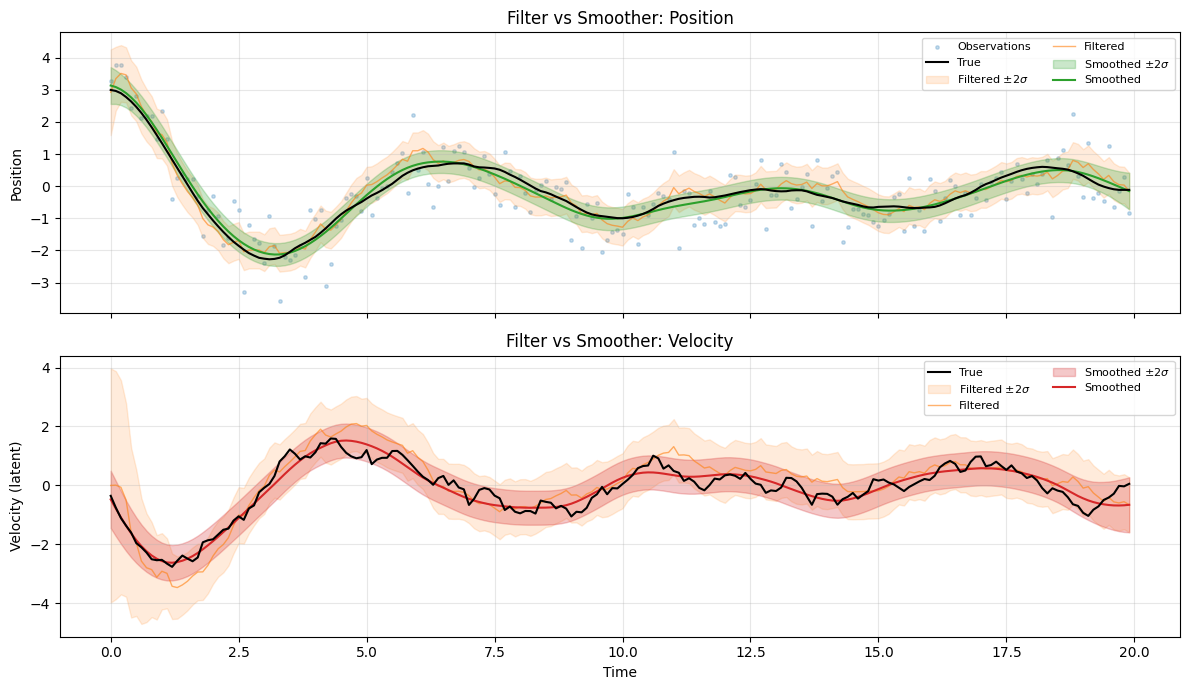

In [7]:
smooth_pos_mean = smoothed_means[:, 0]
smooth_pos_std = jnp.sqrt(smoothed_covs[:, 0, 0])
smooth_vel_mean = smoothed_means[:, 1]
smooth_vel_std = jnp.sqrt(smoothed_covs[:, 1, 1])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: position — overlay filtered and smoothed
ax = axes[0]
ax.scatter(
    times, observations[:, 0], s=6, c="C0", alpha=0.25, label="Observations", zorder=1
)
ax.plot(times, true_position, "k-", lw=1.5, label="True", zorder=4)
ax.fill_between(
    times,
    filt_pos_mean - 2 * filt_pos_std,
    filt_pos_mean + 2 * filt_pos_std,
    color="C1",
    alpha=0.15,
    label=r"Filtered $\pm 2\sigma$",
)
ax.plot(times, filt_pos_mean, "C1-", lw=1, alpha=0.6, label="Filtered", zorder=2)
ax.fill_between(
    times,
    smooth_pos_mean - 2 * smooth_pos_std,
    smooth_pos_mean + 2 * smooth_pos_std,
    color="C2",
    alpha=0.25,
    label=r"Smoothed $\pm 2\sigma$",
)
ax.plot(times, smooth_pos_mean, "C2-", lw=1.5, label="Smoothed", zorder=3)
ax.set_ylabel("Position")
ax.set_title("Filter vs Smoother: Position")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)

# Bottom: velocity — overlay filtered and smoothed
ax = axes[1]
ax.plot(times, true_states[:, 1], "k-", lw=1.5, label="True", zorder=4)
ax.fill_between(
    times,
    filt_vel_mean - 2 * filt_vel_std,
    filt_vel_mean + 2 * filt_vel_std,
    color="C1",
    alpha=0.15,
    label=r"Filtered $\pm 2\sigma$",
)
ax.plot(times, filt_vel_mean, "C1-", lw=1, alpha=0.6, label="Filtered", zorder=2)
ax.fill_between(
    times,
    smooth_vel_mean - 2 * smooth_vel_std,
    smooth_vel_mean + 2 * smooth_vel_std,
    color="C3",
    alpha=0.25,
    label=r"Smoothed $\pm 2\sigma$",
)
ax.plot(times, smooth_vel_mean, "C3-", lw=1.5, label="Smoothed", zorder=3)
ax.set_xlabel("Time")
ax.set_ylabel("Velocity (latent)")
ax.set_title("Filter vs Smoother: Velocity")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Differentiability

The Kalman filter is implemented via `jax.lax.scan`, so it is fully
differentiable. We can compute gradients of the log-likelihood with
respect to model parameters — useful for learning SSM parameters
via gradient-based optimization.

In [8]:
def neg_log_likelihood(log_obs_noise_var):
    """Negative log-likelihood as a function of log observation noise variance."""
    R_param = jnp.exp(log_obs_noise_var) * jnp.eye(1)
    fs = gaussx.kalman_filter(A, H, Q, R_param, observations, init_mean, init_cov)
    return -fs.log_likelihood


# Evaluate at the true value
log_R_true = jnp.log(R[0, 0])
nll = neg_log_likelihood(log_R_true)
grad_nll = jax.grad(neg_log_likelihood)(log_R_true)

print(f"log(R) = {log_R_true:.4f}")
print(f"Negative log-likelihood = {nll:.4f}")
print(f"Gradient d(-LL)/d(log R) = {grad_nll:.4f}")

log(R) = -0.6931
Negative log-likelihood = 223.3189
Gradient d(-LL)/d(log R) = 12.2965


## Summary

- `gaussx.kalman_filter` implements the standard Kalman filter forward pass,
  returning filtered means, covariances, and the total log-likelihood.
- `gaussx.rts_smoother` refines filtered estimates using a backward pass,
  producing tighter credible intervals.
- Both are implemented with `jax.lax.scan` and are fully compatible with
  JAX transforms: `jit`, `vmap`, and `grad` all work out of the box.
- This makes gaussx suitable for learning SSM parameters via gradient-based
  optimization of the log-likelihood.